In [ ]:
!pip install numba

In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import xmltodict
import rasterio
import os
from pathlib import Path
from dateutil.parser import isoparse
from scipy.interpolate import CubicHermiteSpline
from shapely.geometry import box
from eo_tools.util import show_cog
from numba import jit, prange
from folium import Map, LayerControl
from eo_tools.S1_dev import geocode_burst, resample_burst_ampl
import logging
logging.basicConfig(level=logging.INFO)

In [ ]:
data_dir = "/data/S1"
product_dir = f"{data_dir}/S1A_IW_SLC__1SDV_20210624T172451_20210624T172518_038485_048A9C_A58F.SAFE"
file_out = "/data/res/testing_tc.tif"

In [62]:
az, rg, dem_prof = geocode_burst(product_dir, iw=1, pol='vv', burst_idx=5)

INFO:eo_tools.S1_dev:Read input files


INFO:eo_tools.S1_dev:DEM downloading
INFO:eodag.config:Loading user configuration from: /root/.config/eodag/eodag.yml
INFO:eodag.core:usgs: provider needing auth for search has been pruned because no crendentials could be found
INFO:eodag.core:aws_eos: provider needing auth for search has been pruned because no crendentials could be found
INFO:eodag.core:meteoblue: provider needing auth for search has been pruned because no crendentials could be found
INFO:eodag.core:hydroweb_next: provider needing auth for search has been pruned because no crendentials could be found
INFO:eodag.core:wekeo: provider needing auth for search has been pruned because no crendentials could be found
INFO:eodag.core:creodias_s3: provider needing auth for search has been pruned because no crendentials could be found
INFO:eodag.core:Locations configuration loaded from /root/.config/eodag/locations.yml
INFO:eodag.config:Fetching external product types from https://cs-si.github.io/eodag/eodag/resources/ext_produc

Downloaded products:   0%|          | 0/2 [00:00<?, ?product/s]

0.00B [00:00, ?B/s]

INFO:eodag.download.base:Download url: https://planetarycomputer.microsoft.com/api/stac/v1/collections/cop-dem-glo-30/items/Copernicus_DSM_COG_10_N50_00_E005_00_DEM
INFO:eodag.product:Remote location of the product is still available through its 'remote_location' property: https://planetarycomputer.microsoft.com/api/stac/v1/collections/cop-dem-glo-30/items/Copernicus_DSM_COG_10_N50_00_E005_00_DEM


0.00B [00:00, ?B/s]

INFO:eodag.download.base:Download url: https://planetarycomputer.microsoft.com/api/stac/v1/collections/cop-dem-glo-30/items/Copernicus_DSM_COG_10_N50_00_E004_00_DEM
INFO:eodag.product:Remote location of the product is still available through its 'remote_location' property: https://planetarycomputer.microsoft.com/api/stac/v1/collections/cop-dem-glo-30/items/Copernicus_DSM_COG_10_N50_00_E004_00_DEM
INFO:eo_tools.dem:Merging rasters
INFO:eo_tools.dem:Cropping rasters
INFO:eo_tools.dem:Writing file /tmp/dem-b5-s1a-iw1-slc-vv-20210624t172451-20210624t172517-038485-048a9c-004.tiff
INFO:eo_tools.dem:---- Removing temporary files.
INFO:eo_tools.auxils:Removing /tmp/Copernicus_DSM_COG_10_N50_00_E005_00_DEM
INFO:eo_tools.auxils:Removing /tmp/Copernicus_DSM_COG_10_N50_00_E004_00_DEM
INFO:eo_tools.S1_dev:DEM upsampling and extract coordinates
INFO:eo_tools.S1_dev:Convert latitude, longitude & altitude to ECEF x, y & z
INFO:eo_tools.S1_dev:Terrain correction (index computation)


INFO:eo_tools.S1_dev:Read burst


INFO:eo_tools.S1_dev:Warp to match DEM geometry
INFO:eo_tools.S1_dev:Write output GeoTIFF


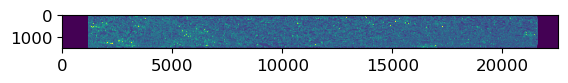

In [63]:
resample_burst_ampl(product_dir , file_out, az, rg, dem_prof, iw=1, pol="vv", burst_idx=5, order=1)

In [68]:
from folium import LayerControl
m = Map()
show_cog(file_out, m, rescale="3,8", expression="log(b1)")
LayerControl().add_to(m)
m

INFO:httpx:HTTP Request: GET http://localhost:8085/cog/info?url=%2Fdata%2Fres%2Ftesting_tc.tif "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: GET http://localhost:8085/cog/tilejson.json?url=%2Fdata%2Fres%2Ftesting_tc.tif&rescale=3%2C8&expression=log%28b1%29 "HTTP/1.1 200 OK"
